# Importing dependencies and loading dataset

In [1]:
import pandas as pd
import numpy as np
import re, string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data=pd.read_csv('/content/drive/MyDrive/Dataset/Reviews.csv')

In [4]:
data.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df=pd.DataFrame(data)

In [6]:
print(df.head())

   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

In [7]:
print(df.shape)

(568454, 10)


# Data Preprocessing

In [8]:
# Drop exact duplicate rows
df = df.drop_duplicates()


In [9]:
# Keep only rows where 'Text' is present
df = df.dropna(subset=["Text"])

In [10]:
# Convert UNIX epoch to datetime
df["Time"] = pd.to_datetime(df["Time"], unit="s")


In [11]:
# ========== 3. SENTIMENT LABELS ==========

def label_sentiment(score):
    if score in [1, 2]:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(label_sentiment)

In [12]:
# Basic length feature
df["Text_Length"] = df["Text"].apply(lambda x: len(x.split()))

print("Cleaned shape:", df.shape)

Cleaned shape: (568454, 12)


In [13]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'Sentiment', 'Text_Length'],
      dtype='object')


# Exploratory Data Analysis

In [14]:
# Sentiment distribution
print("\nSentiment counts:")
print(df["Sentiment"].value_counts())



Sentiment counts:
Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


In [15]:
# Average review length
print("\nAverage cleaned review length (words):", df["Text_Length"].mean())



Average cleaned review length (words): 80.26402312236347


In [16]:
# Top 10 most common words
from collections import Counter
all_words = " ".join(df["Text"]).split()
common_words = Counter(all_words).most_common(10)
print("\nTop 10 most common words:")
for w, c in common_words:
    print(f"{w}: {c}")


Top 10 most common words:
the: 1628045
I: 1388076
and: 1228666
a: 1163164
to: 992367
of: 789652
is: 714264
it: 631252
for: 519983
in: 512394


In [17]:
# Top 5 products by number of reviews
print("\nTop 5 products by review count:")
print(df["ProductId"].value_counts().head())


Top 5 products by review count:
ProductId
B007JFMH8M    913
B002QWHJOU    632
B0026RQTGE    632
B002QWP89S    632
B002QWP8H0    632
Name: count, dtype: int64


# Barplot Of Sentiment label

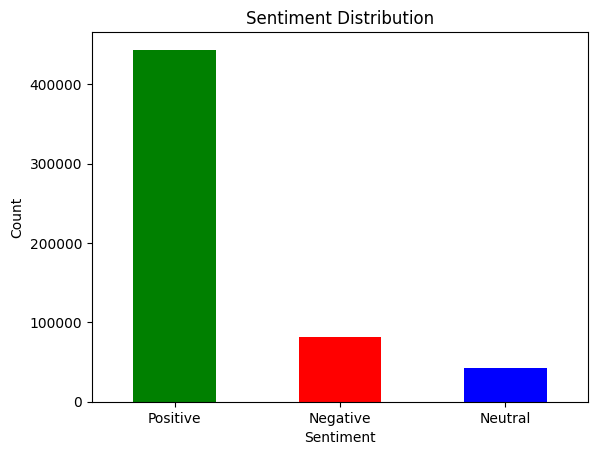

In [24]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()
colors = ['green', 'red', 'blue']  # Green for Positive, Red for Negative, Blue for Neutral
sentiment_counts.plot(kind="bar", color=colors)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

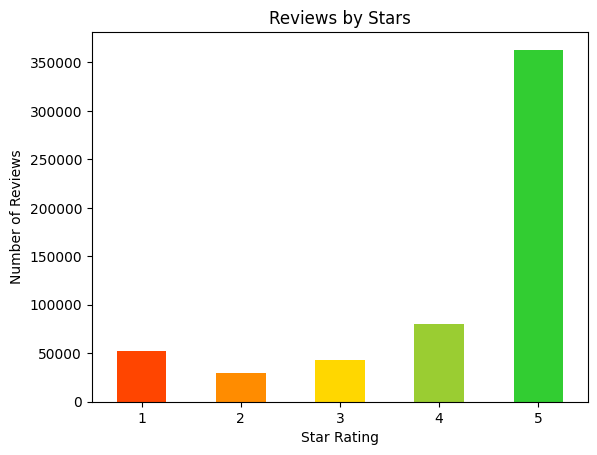

In [25]:
#Plot Of Reviews by Stars
colors = ['#FF4500', '#FF8C00', '#FFD700', '#9ACD32', '#32CD32'] # Different colors for each star rating
df['Score'].value_counts().sort_index().plot(kind='bar', color=colors)
plt.title("Reviews by Stars")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.figsize=(8,6)
plt.show()

In [27]:
# Top 5 most frequent words for positive , neutral and negative reviews
df['review_text'] = df['Summary'].fillna('') + " " + df['Text'].fillna('')


# Text Cleaning

In [28]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import nltk

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [29]:
#Separate Positive & Negative Reviews
positive_reviews = df[df['Sentiment'] == 'Positive']['review_text']
negative_reviews = df[df['Sentiment'] == 'Negative']['review_text']
print(len(positive_reviews))
print(len(negative_reviews))


443777
82037


In [31]:

positive_words = []

for review in positive_reviews:
    positive_words.extend(clean_text(review))

top5_positive = Counter(positive_words).most_common(5)
top5_positive
print("Top 5 Positive Words:", top5_positive)


Top 5 Positive Words: [('great', 215591), ('good', 198323), ('like', 190491), ('coffee', 142166), ('love', 137838)]


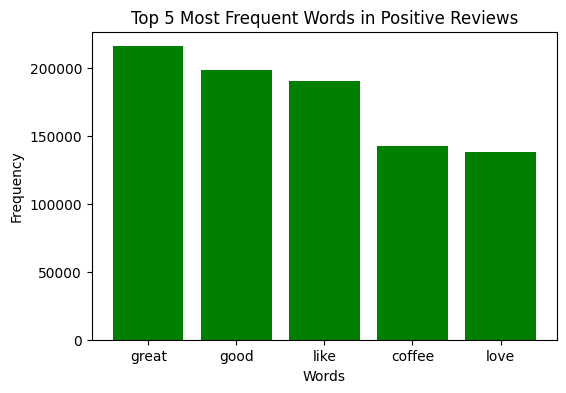

In [32]:
import matplotlib.pyplot as plt

# Separate words and counts in positive reviews
words = [word for word, count in top5_positive]
counts = [count for word, count in top5_positive]
plt.figure(figsize=(6, 4))
plt.bar(words, counts, color='green')
plt.title("Top 5 Most Frequent Words in Positive Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [33]:
# Negative Sentiment
negative_words = []

for review in negative_reviews:
    negative_words.extend(clean_text(review))

top5_negative = Counter(negative_words).most_common(5)
print("Top 5 negative Words:", top5_negative)

Top 5 negative Words: [('like', 47152), ('taste', 34887), ('product', 34047), ('one', 28187), ('would', 27314)]


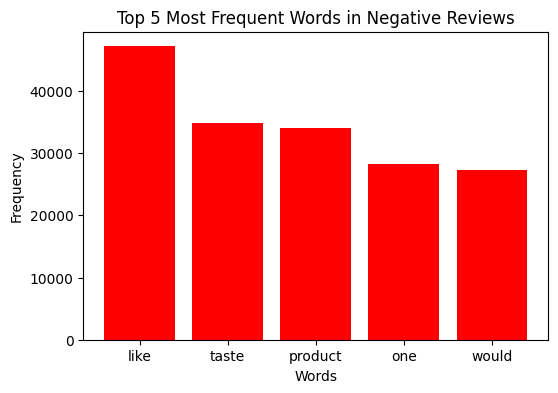

In [34]:
# Negative Review plot
words = [word for word, count in top5_negative]
counts = [count for word, count in top5_negative]
plt.figure(figsize=(6, 4))
plt.bar(words, counts, color='red')
plt.title("Top 5 Most Frequent Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# NLTLK

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
example=df['Text'][10]
print(example)

I don't know if it's the cactus or the tequila or just the unique combination of ingredients, but the flavour of this hot sauce makes it one of a kind!  We picked up a bottle once on a trip we were on and brought it back home with us and were totally blown away!  When we realized that we simply couldn't find it anywhere in our city we were bummed.<br /><br />Now, because of the magic of the internet, we have a case of the sauce and are ecstatic because of it.<br /><br />If you love hot sauce..I mean really love hot sauce, but don't want a sauce that tastelessly burns your throat, grab a bottle of Tequila Picante Gourmet de Inclan.  Just realize that once you taste it, you will never want to use any other sauce.<br /><br />Thank you for the personal, incredible service!


In [ ]:
tokens=nltk.word_tokenize(example)
print(tokens[:10])

['I', 'do', "n't", 'know', 'if', 'it', "'s", 'the', 'cactus', 'or']


In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
from nltk import pos_tag
from nltk.tokenize import word_tokenize

nltk.pos_tag(tokens)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\KAUSHIK\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


[('I', 'PRP'),
 ('do', 'VBP'),
 ("n't", 'RB'),
 ('know', 'VB'),
 ('if', 'IN'),
 ('it', 'PRP'),
 ("'s", 'VBZ'),
 ('the', 'DT'),
 ('cactus', 'NN'),
 ('or', 'CC'),
 ('the', 'DT'),
 ('tequila', 'NN'),
 ('or', 'CC'),
 ('just', 'RB'),
 ('the', 'DT'),
 ('unique', 'JJ'),
 ('combination', 'NN'),
 ('of', 'IN'),
 ('ingredients', 'NNS'),
 (',', ','),
 ('but', 'CC'),
 ('the', 'DT'),
 ('flavour', 'NN'),
 ('of', 'IN'),
 ('this', 'DT'),
 ('hot', 'JJ'),
 ('sauce', 'NN'),
 ('makes', 'VBZ'),
 ('it', 'PRP'),
 ('one', 'CD'),
 ('of', 'IN'),
 ('a', 'DT'),
 ('kind', 'NN'),
 ('!', '.'),
 ('We', 'PRP'),
 ('picked', 'VBD'),
 ('up', 'RP'),
 ('a', 'DT'),
 ('bottle', 'NN'),
 ('once', 'RB'),
 ('on', 'IN'),
 ('a', 'DT'),
 ('trip', 'NN'),
 ('we', 'PRP'),
 ('were', 'VBD'),
 ('on', 'IN'),
 ('and', 'CC'),
 ('brought', 'VBD'),
 ('it', 'PRP'),
 ('back', 'RP'),
 ('home', 'NN'),
 ('with', 'IN'),
 ('us', 'PRP'),
 ('and', 'CC'),
 ('were', 'VBD'),
 ('totally', 'RB'),
 ('blown', 'VBN'),
 ('away', 'RB'),
 ('!', '.'),
 ('When', 'W